In [2]:
!pip install opencv-python-headless -q

In [3]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# input images
input_folder = "/kaggle/input/datasets/satarupadeb/renaissance/image-1628"

# output folder
output_folder = "/kaggle/working/preprocessed-1628"
os.makedirs(output_folder, exist_ok=True)

image_files = sorted(os.listdir(input_folder))
print(f"Total images: {len(image_files)}")

Total images: 12


In [29]:
def preprocess_page(pil_image):
    img = np.array(pil_image)

   

    # grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # CLAHE (light)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # slight smoothing (reduces background noise)
    img = cv2.addWeighted(img, 1.3, cv2.GaussianBlur(img, (0,0), 1), -0.3, 0)

    return Image.fromarray(img).convert("RGB")

In [32]:
processed = []
for img_name in image_files:
    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    img_path  = os.path.join(input_folder, img_name)
    pil_img   = Image.open(img_path).convert("RGB")

    processed_img = preprocess_page(pil_img)

    save_path = os.path.join(output_folder, img_name)
    processed_img.save(save_path)

    processed.append((img_name, pil_img, processed_img))
    print(f"Processed: {img_name}")

print(f"\nDone. {len(processed)} images processed.")

Processed: img_0001.jpg
Processed: img_0002.jpg
Processed: img_0003.jpg
Processed: img_0004.jpg
Processed: img_0005.jpg
Processed: img_0006.jpg
Processed: img_0007.jpg
Processed: img_0008.jpg
Processed: img_0009.jpg
Processed: img_0010.jpg
Processed: img_0011.jpg
Processed: img_0012.jpg

Done. 12 images processed.


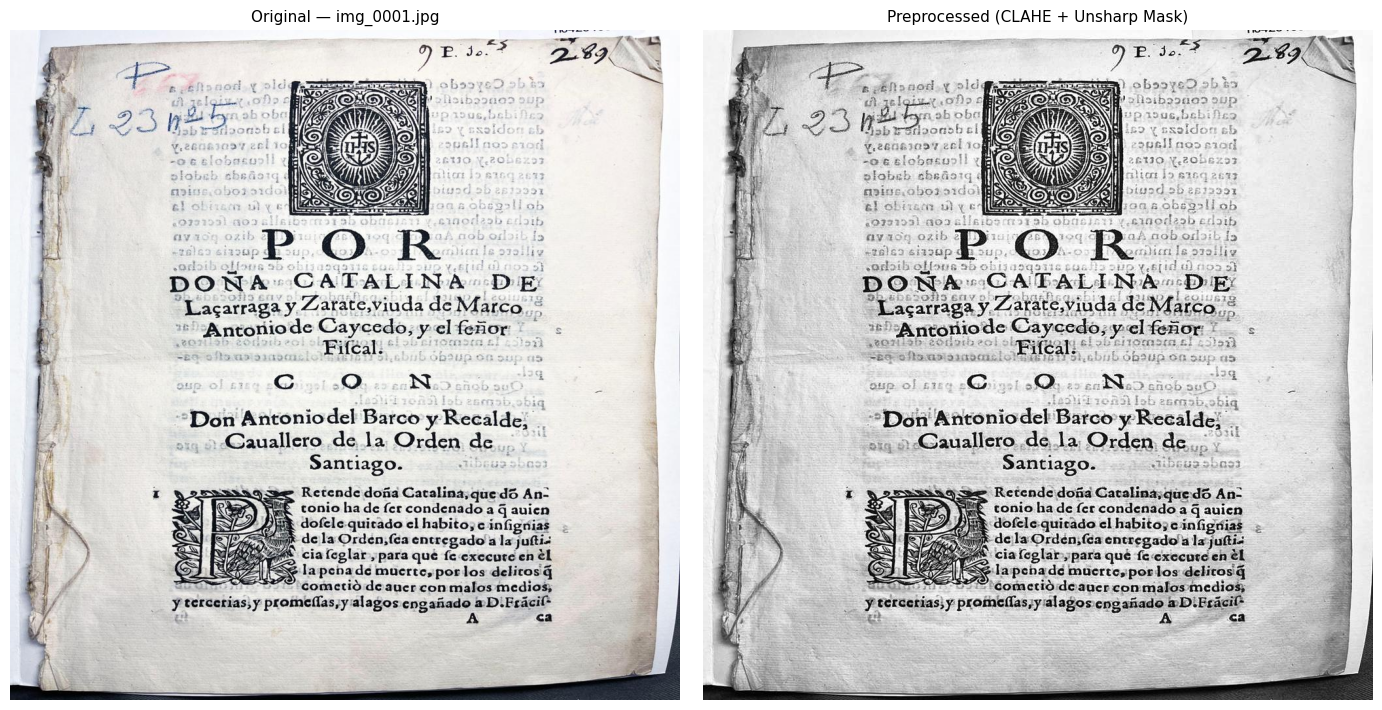

In [33]:
if processed:
    name, original, result = processed[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original)
    axes[0].set_title(f"Original — {name}", fontsize=11)
    axes[0].axis("off")
    axes[1].imshow(result)
    axes[1].set_title("Preprocessed (CLAHE + Unsharp Mask)", fontsize=11)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

In [38]:
!zip -r preprocessed-1628.zip /kaggle/working/preprocessed-1628

updating: kaggle/working/preprocessed-1628/ (stored 0%)
updating: kaggle/working/preprocessed-1628/img_0011.jpg (deflated 0%)
updating: kaggle/working/preprocessed-1628/img_0002.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0006.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0001.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0005.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0004.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0012.jpg (deflated 2%)
updating: kaggle/working/preprocessed-1628/img_0007.jpg (deflated 0%)
updating: kaggle/working/preprocessed-1628/img_0010.jpg (deflated 0%)
updating: kaggle/working/preprocessed-1628/img_0003.jpg (deflated 1%)
updating: kaggle/working/preprocessed-1628/img_0008.jpg (deflated 0%)
updating: kaggle/working/preprocessed-1628/img_0009.jpg (deflated 0%)
